In [48]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point
from tabulate import tabulate
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree

# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost as xgb # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import gstools as gs #variogram modeling
from sklearn.metrics import pairwise_distances # for distance calculations
from scipy.cluster.hierarchy import linkage, dendrogram #for hierarchical clustering dendrogram
from sklearn.cluster import AgglomerativeClustering #for hierarchical clustering
from sklearn.cluster import DBSCAN



#--- Custom Functions as defined by the user ---
import sys
sys.path.append(os.path.abspath("../tools"))
import functions



In [ ]:
print("Current working directory:", os.getcwd())

#load in 
df = pd.read_csv("../../../../data/finaldatasets/testdata/finalfr/testdata.csv")  # for variogram, etc.
print(list(df.columns))



Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering/xgboost
['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Planting.date', 'Treatment', 'Treatment.type', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Irrigation..mm.', 'Soil.type', 'N.type', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Emissions..yes.no.', 'Pest.prescence....64', 'Pest.detected...65', 'Pest.severity.score.......66', 'rainfed_start_date', 'rainfed_end_date', 'irr_start_date', 'irr_end_date', 'start_date', 'end_date', 'Planting.date.1', 'Harvesting.date.1', 'Irrigation.mm_clean', 'irrigation_applied', 'harvest_date_clean', 'harvest_dayofyear', 'harves

/tmp/ipykernel_57226/2607265753.py:4: DtypeWarning: Columns (14,15,16,17,20,22,23,24,26,28,29,30,31,32,39,40,42,43,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../../data/finaldatasets/testdata/finalfr/testdata.csv")  # for variogram, etc.


In [50]:
# Define groups of columns to drop
LOCATION_COLS = [
    "id", "Data.ID", "State.Region.County.Province", "Continent", "Location", "Country",
    "Latitude..N.S.", "Longitude..E.W.", "group", "sowing_year",
    "Observation.period", "Observation.period.1", "Observation.period.2",
    "Location.source", "X", "Y", "unit_code", "Year_x",
    "latitude_jittered","longitude_jittered", "jitter_radius_km", "group_id"
]

# "Conversion.for.latitude", "Conversion.for.longitude"
HIGH_CARDINALITY_COLS = [
    "Treatment.type", "Emissions..yes.no.", 
    "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66",
    "Agricultural_Use_–_Other_Pesticides_nes_(t)","Agricultural_Use_–_Rodenticides_(t)", 
    "irr_end_date", "end_date", "rainfed_end_date"
]


COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# These columns are used for testing purposes
TESTCOLUMNS = [
    "gdp", "hdi", "irr_start_date", "Crop.variety",
    "rainfed_start_date", "Agricultural_Use_._Rodenticides_.t.",
    "Mean.annual.precipitation..mm.", "irrigation_applied", "Sand", "Start_date"
    "Irrigation.mm_clean", "Mean.annual.temperature..Â.C.", "Irrigation.mm_clean", "Wheat.Type", 
]


# Combine all columns to drop into a single set (to avoid duplicates)
COLUMNS_TO_DROP = set(LOCATION_COLS + HIGH_CARDINALITY_COLS + COLLINEAR_COLS + TESTCOLUMNS)

# Drop all listed columns if they exist in the DataFrame
df_cleaned = df.drop(columns=[col for col in COLUMNS_TO_DROP if col in df.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df.shape)
print("Shape after dropping:", df_cleaned.shape)
print("Dropped columns:", [col for col in COLUMNS_TO_DROP if col in df.columns])
print("Remaining columns:", df_cleaned.columns.tolist())

# Drop columns with less than 20% completeness
df_cleaned = df_cleaned.loc[:, df_cleaned.count() / len(df_cleaned) >= 0.2]

# Drop unnamed columns and rows with NaN in the target variable
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned = df_cleaned.dropna(subset=["Grain.yield..tons.ha.1."])


Original shape: (22709, 164)
Shape after dropping: (22709, 122)
Dropped columns: ['Planting_Week', 'Mean.annual.temperature..Â.C.', 'jitter_radius_km', 'irr_start_date', 'rainfed_start_date', 'irrigation_applied', 'Continent', 'Longitude..E.W.', 'Irrigation.mm_clean', 'harvest_date_clean', 'Irrigation..mm.', 'Wheat.Type', 'State.Region.County.Province', 'Sand', 'Country', 'irr_end_date', 'longitude_jittered', 'Planting.date', 'Treatment.type', 'Location', 'Harvesting.date.1', 'Emissions..yes.no.', 'Latitude..N.S.', 'Planting_Month', 'Planting.date.1', 'gdp', 'Observation.period', 'Pest.severity.score.......66', 'end_date', 'harvest_month', 'Location.source', 'sowing_year', 'id', 'group_id', 'Data.ID', 'Mean.annual.precipitation..mm.', 'latitude_jittered', 'Agricultural_Use_._Rodenticides_.t.', 'Crop.variety', 'hdi', 'rainfed_end_date', 'harvest_week']
Remaining columns: ['Conversion.for.latitude', 'Conversion.for.longitude', 'Tillage.type', 'Treatment', 'Grain.yield..tons.ha.1.', 'Wate

In [20]:
functions.summarize_dataframe(df_cleaned)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Country                                               | object  |   22709 |          100   |         37 |
| Trans3                                                | float64 |   22709 |          100   |       1067 |
| Trans1                                                | float64 |   22709 |          100   |       1075 |
| EvapS9                                                | float64 |   22709 |          100   |       1093 |
| EvapS8                                                | float64 |   22709 |          100   |       1095 |
| Conversion.for.latitude                               | float64 |   22709 |          100   |        230 |
| EvapS6                                                | float64 |   22709 |          100   |       1075 |
| EvapS5                    

In [35]:
df_cleaned = df_cleaned.loc[:, df_cleaned.notna().mean() >= 0.5]

### DF filtering

In [62]:
pd.set_option("display.max_rows", None)

# Step 1: Identify locations where ALL rows are after 2018
valid_locs = (
    df_cleaned.groupby("Location")["Observation.period"]
    .min()
    .gt(2018)  # True if min year > 2017
)

# Step 2: Filter to those locations
filtered_df = df_cleaned[df_cleaned["Location"].isin(valid_locs[valid_locs].index)]

In [63]:
len(filtered_df)

1107

In [67]:
filtered_df['Country'].value_counts()

Country
Ethiopia                    692
Afghanistan                  78
Iran                         78
Serbia                       78
Turkey                       76
Ukraine                      39
China                        26
United States of America     24
Japan                         8
Sweden                        8
Name: count, dtype: int64

In [39]:
functions.summarize_dataframe(df_cleaned)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Location                                              | object  |   22709 |          100   |        228 |
| Trans5                                                | float64 |   22709 |          100   |       1008 |
| Trans3                                                | float64 |   22709 |          100   |       1067 |
| Trans2                                                | float64 |   22709 |          100   |       1075 |
| Trans1                                                | float64 |   22709 |          100   |       1075 |
| Conversion.for.latitude                               | float64 |   22709 |          100   |        230 |
| EvapS8                                                | float64 |   22709 |          100   |       1095 |
| EvapS7                    

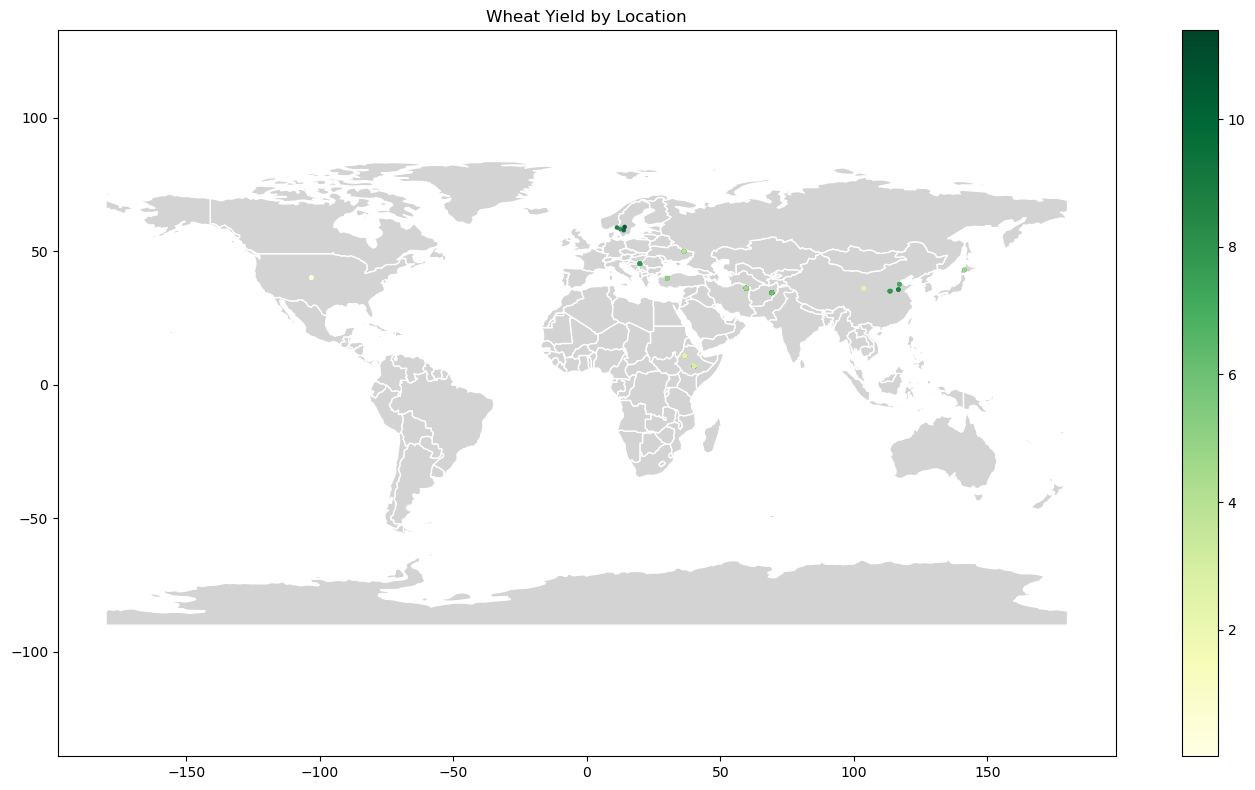

In [56]:
# Step 1: Create GeoDataFrame from your data
gdf = gpd.GeoDataFrame(
    filtered_df.dropna(subset=['Conversion.for.latitude', 'Conversion.for.longitude', 'Grain.yield..tons.ha.1.']),  # drop rows missing coords or yield
    geometry=gpd.points_from_xy(
        filtered_df['Conversion.for.longitude'],
        filtered_df['Conversion.for.latitude']
    ),
    crs="EPSG:4326"
)

# Step 2: Load world basemap from Natural Earth (high-res via GitHub)
world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)

# Step 3: Plot yield values on map
ax = world.plot(figsize=(14, 8), color='lightgray', edgecolor='white')
gdf.plot(ax=ax, column='Grain.yield..tons.ha.1.', cmap='YlGn', markersize=5, legend=True, alpha=0.6)

plt.title("Wheat Yield by Location")
plt.axis('equal')
plt.tight_layout()
plt.show()

##### Create a mask for NA 

In [104]:
# # Approximate bounding box for North America
# na_mask = (
#     (df_cleaned['Conversion.for.latitude'] >= 7) &   # Southern Mexico / Central America
#     (df_cleaned['Conversion.for.latitude'] <= 84) &  # Top of Canada
#     (df_cleaned['Conversion.for.longitude'] >= -170) &  # Western Alaska
#     (df_cleaned['Conversion.for.longitude'] <= -40)     # Eastern Canada / Atlantic
# )

# df_cleaned = df_cleaned[na_mask].copy()


In [115]:
#see how many labels there are before doing rf: 
df_cleaned.select_dtypes(include="object").nunique().sort_values(ascending=False)


Treatment_Category      14
Pest.prescence....64     2
dtype: int64

In [116]:
functions.summarize_dataframe(df_cleaned)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Conversion.for.latitude                               | float64 |   22709 |          100   |        230 |
| Trans5                                                | float64 |   22709 |          100   |       1008 |
| Trans3                                                | float64 |   22709 |          100   |       1067 |
| Trans2                                                | float64 |   22709 |          100   |       1075 |
| Trans1                                                | float64 |   22709 |          100   |       1075 |
| Conversion.for.longitude                              | float64 |   22709 |          100   |        230 |
| EvapS8                                                | float64 |   22709 |          100   |       1095 |
| EvapS7                    

### Onehot encode and prepare data

In [36]:
# Start fresh
X = df_cleaned.copy()
y = X.pop("Grain.yield..tons.ha.1.")

# Add spatial coordinates
X["lon"] = df_cleaned["Conversion.for.longitude"]
X["lat"] = df_cleaned["Conversion.for.latitude"]

# Identify categorical columns
object_cols = X.select_dtypes(include="object").columns.tolist()

# One-hot encode all categorical features (no LabelEncoder needed)
X_encoded = pd.get_dummies(X, columns=object_cols, drop_first=False)

# Ensure all features are numeric (XGBoost-friendly)
X_encoded = X_encoded.astype(float)

# Optional: make all columns visible in output
pd.set_option('display.max_columns', None)

X_encoded.head()

,Conversion.for.latitude,Conversion.for.longitude,N.rate..kg.N.ha.1.,start_date,year,Agricultural_Use_._Fungicides_and_Bactericides_.t.,Agricultural_Use_._Herbicides_.t.,Agricultural_Use_._Insecticides_.t.,Agricultural_Use_._Pesticides_.total._.t.,Use_per_area_of_cropland_._Pesticides_.total._.kg.ha.,gdp_per_capita,prc1,prc2,prc3,prc4,prc5,prc6,prc7,prc8,prc9,NDVI1,NDVI2,NDVI3,NDVI4,NDVI5,NDVI6,NDVI7,NDVI8,NDVI9,Evap1,Evap2,Evap3,Evap4,Evap5,Evap6,Evap7,Evap8,Evap9,EvapS1,EvapS2,EvapS3,EvapS4,EvapS5,EvapS6,EvapS7,EvapS8,EvapS9,SoilM1,SoilM2,SoilM3,SoilM4,SoilM5,SoilM6,SoilM7,SoilM8,SoilM9,Trans1,Trans2,Trans3,Trans4,Trans5,Trans6,Trans7,Trans8,Trans9,Elevation,AEZ,Clay,Silt,Soil.pH,Soil.organic.carbon..g.C.kg.1.,pr_irrigated,Soil_N,temp1,temp2,temp3,temp4,temp5,temp6,temp7,temp8,temp9,lai_month_1,lai_month_2,lai_month_3,lai_month_4,lai_month_5,lai_month_6,lai_month_7,fpar_month_1,fpar_month_2,fpar_month_3,fpar_month_4,fpar_month_5,fpar_month_6,fpar_month_7,lon,lat,Pest.prescence....64_No,Pest.prescence....64_Yes,Treatment_Category_Application Methods,Treatment_Category_Combined Organic-Inorganic,Treatment_Category_Control,Treatment_Category_Crop Residue & Plant-based,Treatment_Category_Enhanced Efficiency,Treatment_Category_Inorganic Nitrogen,Treatment_Category_Micronutrients & Secondary,Treatment_Category_Mineral Fertilizers,Treatment_Category_NPK Complex,Treatment_Category_Nitrogen Rate Treatments,Treatment_Category_Organic Animal-based,Treatment_Category_Other,Treatment_Category_Phosphorus & Potassium,Treatment_Category_Specialty Treatments
0,38.433333,-121.866667,0.0,10.0,2010.0,21923.6,225586.43,63956.47,374818.2,2.28,49041.0,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,0.448000,0.421333,0.397333,0.446667,0.508000,0.553333,0.473333,0.457333,0.505333,28.626282,25.154013,13.393006,17.376251,22.632946,50.134106,62.424496,83.021912,55.370033,0.393874,0.537292,0.714153,0.838182,0.743973,0.655773,0.638705,0.546504,0.289259,0.189219,0.18297,0.199029,0.270979,0.330015,0.319356,0.309855,0.252335,0.205921,16.834427,16.114462,4.584987,5.545164,11.715911,38.949978,45.2047,70.407593,50.29298,19.0,27.0,31.200001,42.500000,6.833333,15.600000,75.305054,1.700000,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,0.8,0.68,0.4,0.82,1.62,1.54,1.45,0.512,0.482,0.334,0.51,0.666,0.586,0.5525,-121.866667,38.433333,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,38.433333,-121.866667,91.0,10.0,2010.0,21923.6,225586.43,63956.47,374818.2,2.28,49041.0,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,0.448000,0.421333,0.397333,0.446667,0.508000,0.553333,0.473333,0.457333,0.505333,28.626282,25.154013,13.393006,17.376251,22.632946,50.134106,62.424496,83.021912,55.370033,0.393874,0.537292,0.714153,0.838182,0.743973,0.655773,0.638705,0.546504,0.289259,0.189219,0.18297,0.199029,0.270979,0.330015,0.319356,0.309855,0.252335,0.205921,16.834427,16.114462,4.584987,5.545164,11.715911,38.949978,45.2047,70.407593,50.29298,20.0,27.0,29.600000,38.333332,6.933333,12.483334,75.305054,1.400000,15.728022,12.878931,9.996943,9.012903,10.314661,11.100946,15.295618,19.073236,25.414057,0.8,0.68,0.4,0.82,1.62,1.54,1.45,0.512,0.482,0.334,0.51,0.666,0.586,0.5525,-121.866667,38.433333,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,38.433333,-121.866667,151.0,10.0,2010.0,21923.6,225586.43,63956.47,374818.2,2.28,49041.0,2.304529,3.883288,3.851088,4.177955,1.567845,3.587905,0.29359,0.504007,0.000765,0.448000,0.421333,0.397333,0.446667,0.508000,0.553333,0.473333,0.457333,0.505333,28.626282,25.154013,13.393006,17.376251,22.632946,50.134106,62.424496,83.021912,55.370033,0.393874,0.537292,0.714153,0.838182,0.743973,0.655773,0.638705,0.546504,0.289259,0.189219,0.18297,0.199029,0.270979,0.330015,0.319356,0.309855,0.252335,0.205921,16.834427,16.114462,4.584987,5.545164,11.715911,38.949978,45.2047,70.407593,50.29298,19.0,27.0,31.600000,41.333332,6.900

RF with spacial and temporal blocking? 

In [118]:
#🌍 BLOCK 2: Spatial Grouping (Haversine Clustering)

# group coordinates for spatial grouping
coords = df_cleaned[['Conversion.for.latitude', 'Conversion.for.longitude']].dropna().values
# creates spatial groups for farms near each other using haversine distance (great-circle distance on earth's surface)
coords_rad = np.deg2rad(coords)
tree = BallTree(coords_rad, metric='haversine')
radius_km = 50
radius = radius_km / 6371.0

# this code loops through all coordinates and groups them based on haversine distance
groups, visited = [], np.zeros(len(coords), dtype=bool)
for i in range(len(coords)):
    if not visited[i]:
        inds = tree.query_radius([coords_rad[i]], r=radius)[0]
        groups.append(inds)
        visited[inds] = True

spatial_group_labels = np.zeros(len(coords), dtype=int)
for group_id, inds in enumerate(groups):
    spatial_group_labels[inds] = group_id

df_cleaned.loc[
    df_cleaned[['Conversion.for.latitude', 'Conversion.for.longitude']].dropna().index,
    'spatial_group'
] = spatial_group_labels


In [76]:
#⏳ BLOCK 3–4: Temporal & Combined Group Labels
temporal_groups = df_cleaned['Observation.period'].astype(str).values

combined_groups = np.array([
    f"S{int(spatial)}_T{temporal}" 
    for spatial, temporal in zip(df_cleaned['spatial_group'], temporal_groups)
])

print(len(combined_groups))

22709


#### AGGLOMETRIC HEIRARCHICAL CLUSTERING (SPACE AND TIME)

In [23]:
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import pandas as pd

# -------------------------
# Haversine Distance Matrix
# -------------------------
def haversine_distance_matrix(coords_rad):
    # Extract lat/lon columns
    lat = coords_rad[:, 0][:, np.newaxis]
    lon = coords_rad[:, 1][:, np.newaxis]

    # Pairwise differences
    dlat = lat - lat.T
    dlon = lon - lon.T

    # Haversine formula for great-circle distance
    a = np.sin(dlat / 2)**2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # Convert radians to kilometers (Earth radius)

# -------------------------
# Per-Year Agglomerative Clustering
# -------------------------
def agglomerative_by_year(df, lat_col, lon_col, time_col, radius_km):
    df['spatial_group'] = np.nan  # Create empty column to store spatial group labels

    for year in df[time_col].dropna().unique():  # Loop through each year in time_col in order to stratify spatial groups
        year_mask = df[time_col] == year
        coords_df = df.loc[year_mask, [lat_col, lon_col]]

        valid_mask = coords_df.notna().all(axis=1)  # Filter out rows with missing coordinates
        coords_rad = np.radians(coords_df[valid_mask].values)  # Convert degrees to radians

        dist_matrix = haversine_distance_matrix(coords_rad)  # Compute Haversine distance matrix

        # Run Agglomerative Clustering with complete linkage on precomputed distances
        model = AgglomerativeClustering(
            metric='precomputed',
            linkage='complete',
            distance_threshold=radius_km,
            n_clusters=None
        )
        labels = model.fit_predict(dist_matrix)  # Predict cluster labels

        # Offset labels by year to ensure uniqueness across years
        full_indices = coords_df[valid_mask].index
        df.loc[full_indices, 'spatial_group'] = labels + (year * 1000)

    df['spatial_group'] = df['spatial_group'].astype("Int64")  # Cast to nullable integer
    return df  # Return updated DataFrame with spatial group labels


In [ ]:
X_encoded = agglomerative_by_year(
    X_encoded,
    lat_col='Conversion.for.latitude',
    lon_col='Conversion.for.longitude',
    time_col='Observation.period',
    radius_km=100
)


In [44]:
temporal_groups = X_encoded['Observation.period'].astype(str).values

combined_groups = np.array([
    f"S{int(spatial)}_T{temporal}"
    if pd.notnull(spatial) else "missing"
    for spatial, temporal in zip(X_encoded['spatial_group'], temporal_groups)
])

X_encoded['combined_group'] = combined_groups


### Agglometric clustering (space only)

In [2]:
# -------------------------
# Haversine Distance Matrix
# -------------------------
def haversine_distance_matrix(coords_rad):
    lat = coords_rad[:, 0][:, np.newaxis]
    lon = coords_rad[:, 1][:, np.newaxis]

    dlat = lat - lat.T
    dlon = lon - lon.T

    a = np.sin(dlat / 2)**2 + np.cos(lat) * np.cos(lat.T) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # Earth's radius in km

# -------------------------
# Spatial Agglomerative Clustering (on unique locations only)
# -------------------------
def agglomerative_spatial(df, lat_col, lon_col, radius_km):
    df = df.copy()

    # 1. Extract and deduplicate valid coordinates
    coords_df = df[[lat_col, lon_col]].dropna().drop_duplicates().reset_index(drop=False)
    coords_rad = np.radians(coords_df[[lat_col, lon_col]].values)

    # 2. Compute distance matrix and cluster
    dist_matrix = haversine_distance_matrix(coords_rad)
    model = AgglomerativeClustering(
        metric='precomputed',
        linkage='complete',
        distance_threshold=radius_km,
        n_clusters=None
    )
    labels = model.fit_predict(dist_matrix)

    # 3. Assign cluster labels to the unique coordinate rows
    coords_df['spatial_group'] = labels

    # 4. Merge labels back to the original DataFrame
    df = df.merge(coords_df[[lat_col, lon_col, 'spatial_group']], on=[lat_col, lon_col], how='left')

    # 5. Ensure spatial_group is nullable Int
    df['spatial_group'] = df['spatial_group'].astype("Int64")

    return df

In [3]:
X_encoded = agglomerative_spatial(
    X_encoded,
    lat_col='Conversion.for.latitude',
    lon_col='Conversion.for.longitude',
    radius_km=25
)


NameError: name 'X_encoded' is not defined

In [41]:
functions.summarize_dataframe(X_encoded)

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| Conversion.for.latitude                               | float64 |   22709 |          100   |        230 |
| Trans9                                                | float64 |   22709 |          100   |       1070 |
| temp5                                                 | float64 |   22707 |          100   |        659 |
| temp4                                                 | float64 |   22707 |          100   |        658 |
| temp3                                                 | float64 |   22707 |          100   |        650 |
| temp2                                                 | float64 |   22707 |          100   |        637 |
| temp1                                                 | float64 |   22707 |          100   |        630 |
| pr_irrigated              

In [ ]:
X_encoded['combined_group'].value_counts()

In [43]:
combined_groups = X_encoded['spatial_group']

In [46]:
pd.set_option("display.max_rows", None)

# Step 1: Identify locations where ALL rows are after 2018
valid_locs = (
    X_encoded.groupby("combined_group")["Observation.period"]
    .min()
    .gt(2017)  # True if min year > 2017
)

# Step 2: Filter to those combined_groups
filtered_df = X_encoded[X_encoded["combined_group"].isin(valid_locs[valid_locs].index)]

In [47]:
filtered_df.groupby("combined_group").size()

combined_group
S2018000_T2018.0     14
S2018001_T2018.0     16
S2018002_T2018.0     17
S2018003_T2018.0     40
S2018004_T2018.0     14
S2018005_T2018.0     36
S2018006_T2018.0     73
S2018007_T2018.0     40
S2018008_T2018.0     36
S2018009_T2018.0     11
S2018010_T2018.0     36
S2018011_T2018.0     76
S2018012_T2018.0     40
S2018013_T2018.0     12
S2018014_T2018.0     36
S2018015_T2018.0     36
S2018016_T2018.0     40
S2018017_T2018.0     76
S2018018_T2018.0     40
S2018019_T2018.0     40
S2018020_T2018.0    500
S2018021_T2018.0     76
S2018022_T2018.0     40
S2018023_T2018.0    150
S2018024_T2018.0     40
S2018025_T2018.0     36
S2018026_T2018.0     74
S2018027_T2018.0      4
S2018028_T2018.0      4
S2018029_T2018.0     40
S2018030_T2018.0      4
S2018031_T2018.0    500
S2018032_T2018.0    500
S2018033_T2018.0      4
S2018034_T2018.0     40
S2018035_T2018.0    500
S2018036_T2018.0      2
S2018037_T2018.0      2
S2018038_T2018.0     76
S2018039_T2018.0    399
S2018040_T2018.0     36
S

In [65]:
# Distribution of rows per group
group_counts = pd.Series(combined_groups).value_counts()
print("\nGroup size distribution:")
print(group_counts.describe())

# Optional: show smallest and largest groups
print("\nTop 5 smallest groups:")
print(group_counts.sort_values().head())

print("\nTop 5 largest groups:")
print(group_counts.sort_values(ascending=False).head())


Group size distribution:
count    427.00000
mean      53.18267
std      106.13710
min        1.00000
25%        4.00000
50%       12.00000
75%       47.50000
max      500.00000
Name: count, dtype: float64

Top 5 smallest groups:
S2008015_T2008.0    1
S2006007_T2006.0    1
S2014029_T2014.0    1
S2013017_T2013.0    1
S2010015_T2010.0    1
Name: count, dtype: int64

Top 5 largest groups:
S2013003_T2013.0    500
S2017014_T2017.0    500
S2017029_T2017.0    500
S2018035_T2018.0    500
S2017019_T2017.0    500
Name: count, dtype: int64


Define Training and testing set (prepare for agony)

In [44]:
# Define the seed for reproducibility
SEED = 42
np.random.seed(SEED)

# Drop only columns that exist in X_encoded
cols_to_drop = ["Conversion.for.latitude", "Conversion.for.longitude", "spatial_group"]
X_encoded = X_encoded.drop(columns=[col for col in cols_to_drop if col in X_encoded.columns])


X_trainval, X_test, y_trainval, y_test, groups_trainval, groups_test = train_test_split(
    X_encoded,
    y,
    combined_groups,
    test_size=0.2,
    random_state=SEED,
    stratify=None  # Remove or set to None if group balance is poor
)

print(f"Train/Validation size: {X_trainval.shape[0]}")
print(f"Holdout test size:     {X_test.shape[0]}")


Train/Validation size: 18167
Holdout test size:     4542


In [46]:
# 🌲 BLOCK 5: XGBoost Regressor + Random Search + GroupKFold
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv = GroupKFold(n_splits=10)

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    missing=np.nan,
    n_jobs=os.cpu_count() - 1,
    random_state=SEED
)

param_dist = {
    "n_estimators": [100, 250, 500],
    "max_depth": [4, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=cv.split(X_trainval, y_trainval, groups=groups_trainval),
    verbose=1,
    n_jobs= 4,
    random_state=SEED
)

search.fit(X_trainval, y_trainval)
best_model = search.best_estimator_

Fitting 10 folds for each of 20 candidates, totalling 200 fits


Final model running

Final model trained in 0.03 minutes.
Holdout Test Set Evaluation Metrics:
  MAE : 0.7892
  RMSE: 1.1041
  R²  : 0.7518


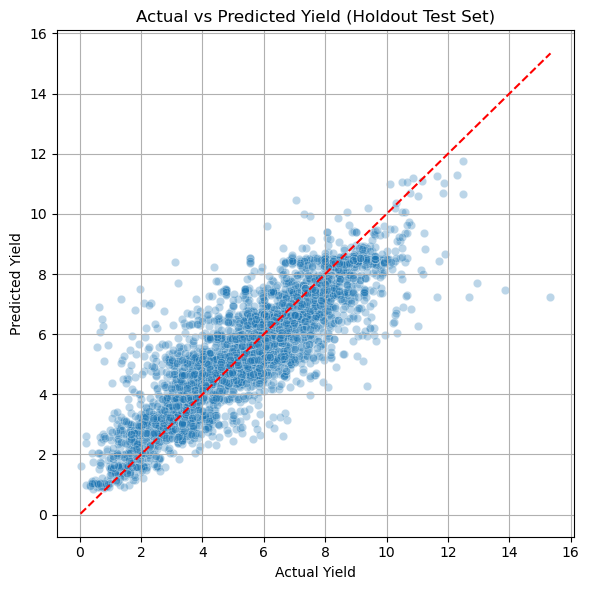

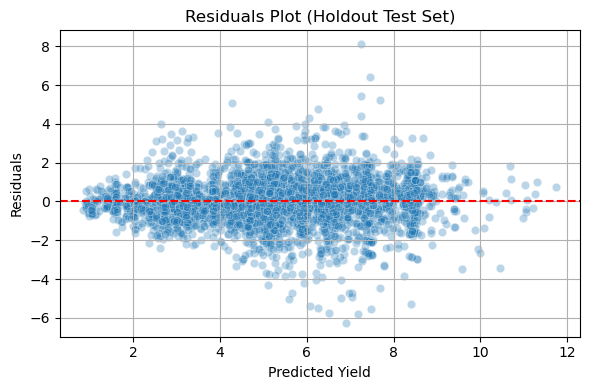

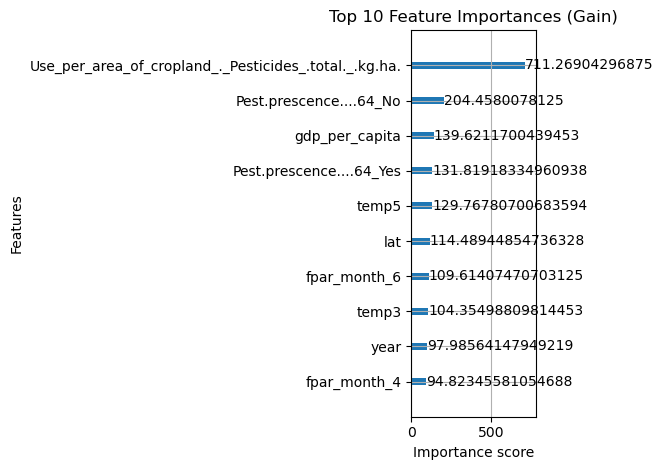

/tmp/ipykernel_57226/1929559830.py:66: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


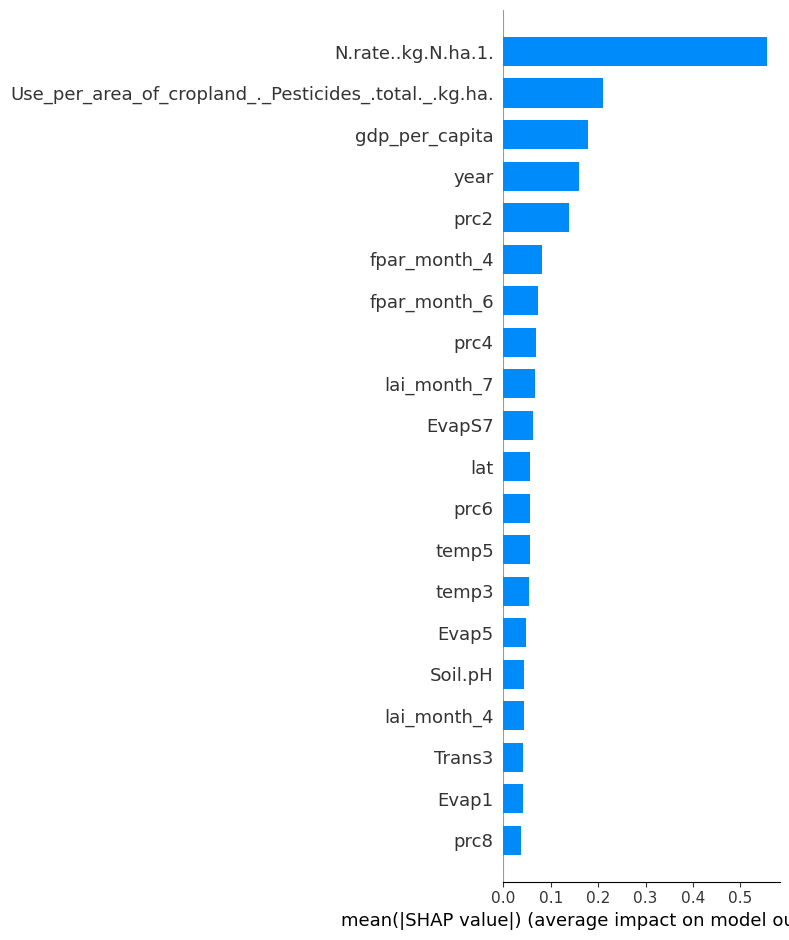

/tmp/ipykernel_57226/1929559830.py:69: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


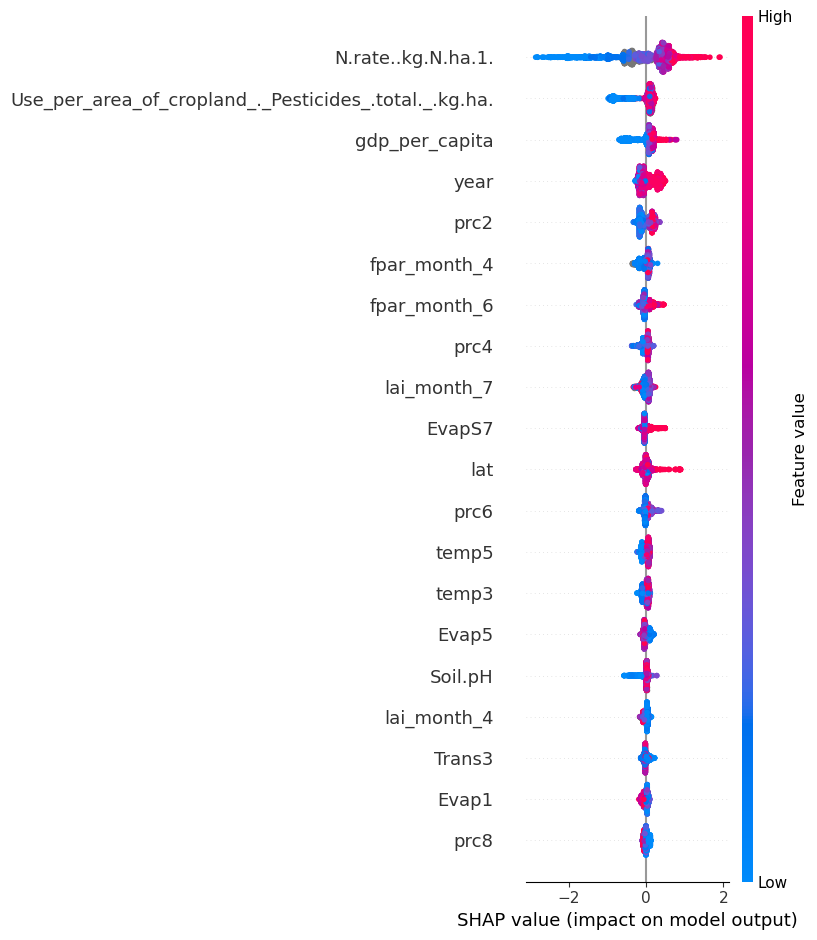

In [47]:
# Use best parameters from random search
best_params = search.best_params_

# Build final model
best_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    tree_method="hist",
    missing=np.nan,
    n_jobs=os.cpu_count() - 1,
    random_state=0
)

# Train on full training+validation set
start_time = time.time()
best_model.fit(X_trainval, y_trainval)
print(f"Final model trained in {(time.time() - start_time)/60:.2f} minutes.")

# Predict on holdout test set
y_pred = best_model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Holdout Test Set Evaluation Metrics:")
print(f"  MAE : {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²  : {r2:.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield (Holdout Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residuals Plot
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")
plt.title("Residuals Plot (Holdout Test Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Feature Importance (XGBoost native)
xgb.plot_importance(best_model, importance_type='gain', max_num_features=10)
plt.title("Top 10 Feature Importances (Gain)")
plt.tight_layout()
plt.show()

# SHAP Explanation (on test data or a sample subset)
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

# SHAP Summary: Bar Plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

# SHAP Summary: Beeswarm Plot
shap.summary_plot(shap_values, X_test)

